## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [ ]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo

In [103]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.metrics import r2_score
import statsmodels.formula.api as smf
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.outliers_influence import OLSInfluence

In [2]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

In [4]:
X.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0


In [3]:
y.head()

,area
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [5]:
X.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000


In [6]:
y.describe()

,area
count,517.000000
mean,12.847292
std,63.655818
min,0.000000
25%,0.000000
50%,0.520000
75%,6.570000
max,1090.840000


In [9]:
data = X
data['area'] = y

In [10]:
data.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [42]:
dX = data[['temp','RH','wind','rain']]
dy = data['area']

In [43]:
dX.shape , dy.shape

((517, 4), (517,))

In [44]:
X_const = sm.add_constant(dX)
model = sm.OLS(y , X_const).fit()
residuals = model.resid
fitted = model.fittedvalues

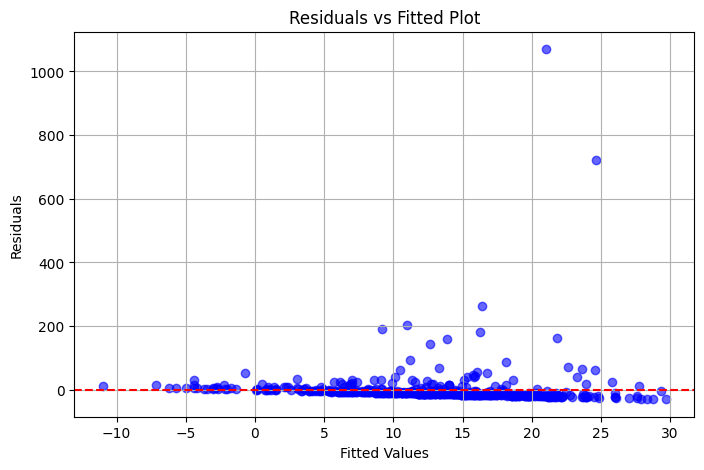

In [45]:
plt.figure(figsize=(8,5))
plt.scatter(fitted, residuals, color = 'blue', alpha= 0.6)
plt.axhline(0, color= 'red', linestyle ='--')
plt.title('Residuals vs Fitted Plot')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


# In this residuals vs fitted plot there are 2 extreme residuals 

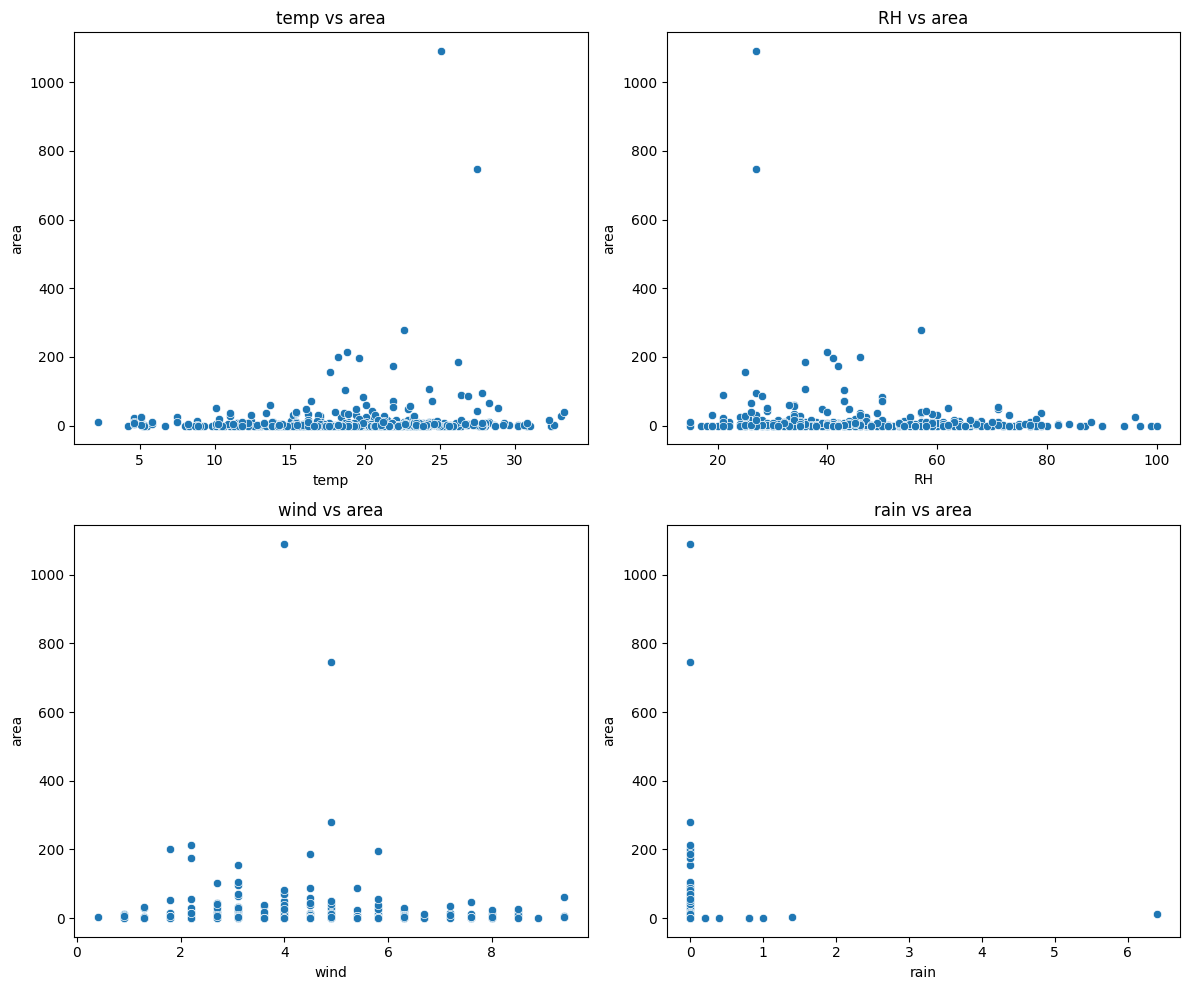

In [ ]:
fig, axes = plt.subplots(2, 2, figsize= (12,10))
predictors = ['temp','RH','wind','rain']
target = 'area'
axes = axes.flatten()
for i, col in enumerate(predictors):
    sns.scatterplot(x=data[col], y=data[target], ax=axes[i])
    axes[i].set_title(f'{col} vs area')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('area')

plt.tight_layout()
plt.show()

#it look like most of the clusters are near zero so small fires dominate the data set
# rain value are near zero. It likely do to little rainfall

Text(0.5, 1.0, 'Correlation Matrix of Predictors')

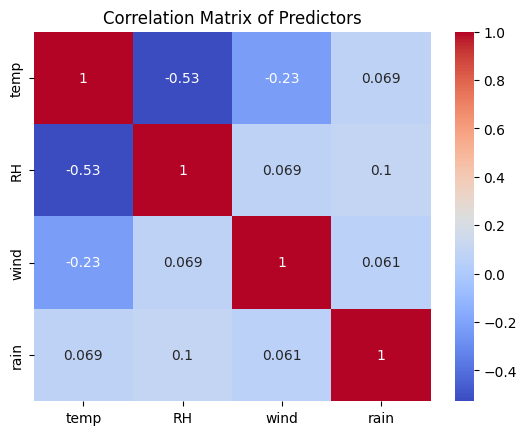

In [ ]:
correlation_matrix = dX.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Predictors')
# it look like a strong negative correlation (-0.53)temperature vs Relative Humidity 
# - hotter days tend to have lower Humidity 
#it look like Temp vs Wind mild negative correlation (-0.23) 
# in the Rain column are near zero 

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [62]:
model.summary()
# Based on the model summary the model do not fit.  

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   area   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.512
Date:                Sat, 25 Oct 2025   Prob (F-statistic):              0.197
Time:                        21:18:18   Log-Likelihood:                -2877.4
No. Observations:                 517   AIC:                             5765.
Df Residuals:                     512   BIC:                             5786.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.4385     20.159     -0.319      0.750     -46.043      33.166
temp           1.0096      0.589      1.713      0.087      -0.148       2.168
RH            -0.1098      0.205     -0.535      0.593      -0.512       0.293
wind           1.2787      1.612      0.793      0.428      -1.889       4.447
rain          -2.8302      9.637     -0.294      0.769     -21.763      16.103
==============================================================================
Omnibus:                      978.182   Durbin-Watson:                   1.641
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           789231.331
Skew:                          12.658   Prob(JB):                         0.00
Kurtosis:                     192.728   Cond. No.                         365.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [73]:
data['temp2'] = data['temp']** 2
quad_model = smf.ols(formula='area ~ temp + temp2 ', data=data).fit()
quad_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   area   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.931
Date:                Sat, 25 Oct 2025   Prob (F-statistic):             0.0542
Time:                        23:24:07   Log-Likelihood:                -2877.5
No. Observations:                 517   AIC:                             5761.
Df Residuals:                     514   BIC:                             5774.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.3577     19.264      0.434      0.665     -29.489      46.204
temp          -0.8984      2.149     -0.418      0.676      -5.120       3.323
temp2          0.0550      0.058      0.941      0.347      -0.060       0.170
==============================================================================
Omnibus:                      978.349   Durbin-Watson:                   1.650
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           790215.118
Skew:                          12.662   Prob(JB):                         0.00
Kurtosis:                     192.847   Cond. No.                     3.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [64]:
interaction_model = smf.ols(formula='area ~ temp * RH + wind * rain', data=data).fit()
interaction_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   area   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.176
Date:                Sat, 25 Oct 2025   Prob (F-statistic):              0.318
Time:                        21:26:26   Log-Likelihood:                -2876.9
No. Observations:                 517   AIC:                             5768.
Df Residuals:                     510   BIC:                             5798.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -25.5825     27.818     -0.920      0.358     -80.234      29.069
temp           2.1305      1.288      1.655      0.099      -0.399       4.660
RH             0.3104      0.475      0.654      0.513      -0.622       1.243
temp:RH       -0.0274      0.028     -0.966      0.335      -0.083       0.028
wind           1.4983      1.637      0.915      0.360      -1.718       4.714
rain          13.9098     73.022      0.190      0.849    -129.552     157.371
wind:rain     -2.9856     14.347     -0.208      0.835     -31.172      25.201
==============================================================================
Omnibus:                      975.588   Durbin-Watson:                   1.637
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           777320.392
Skew:                          12.589   Prob(JB):                         0.00
Kurtosis:                     191.283   Cond. No.                     2.21e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.21e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [65]:
dry_rain_threshold = 0.0
dry_rh_threshold = 40 
data['is_dry_day'] = ((data['rain'] <= dry_rain_threshold)& (data['RH']<= dry_rh_threshold)).astype(int)
data[['rain','RH','is_dry_day']].head()

,rain,RH,is_dry_day
0,0.0,51,0
1,0.0,33,1
2,0.0,33,1
3,0.2,97,0
4,0.0,99,0


In [66]:
indicator_model = smf.ols('area ~ temp + rain + RH + is_dry_day', data=data).fit()
indicator_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   area   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.358
Date:                Sat, 25 Oct 2025   Prob (F-statistic):              0.248
Time:                        22:17:04   Log-Likelihood:                -2877.7
No. Observations:                 517   AIC:                             5765.
Df Residuals:                     512   BIC:                             5787.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8943     21.396      0.135      0.892     -39.141      44.930
temp           0.9048      0.575      1.575      0.116      -0.224       2.034
rain          -2.1409      9.603     -0.223      0.824     -21.008      16.726
RH            -0.1478      0.284     -0.521      0.603      -0.705       0.409
is_dry_day    -1.1463      8.707     -0.132      0.895     -18.253      15.960
==============================================================================
Omnibus:                      978.735   Durbin-Watson:                   1.648
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           791257.625
Skew:                          12.673   Prob(JB):                         0.00
Kurtosis:                     192.971   Cond. No.                         396.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [67]:
data['log_area'] = np.log(data['area']+1)

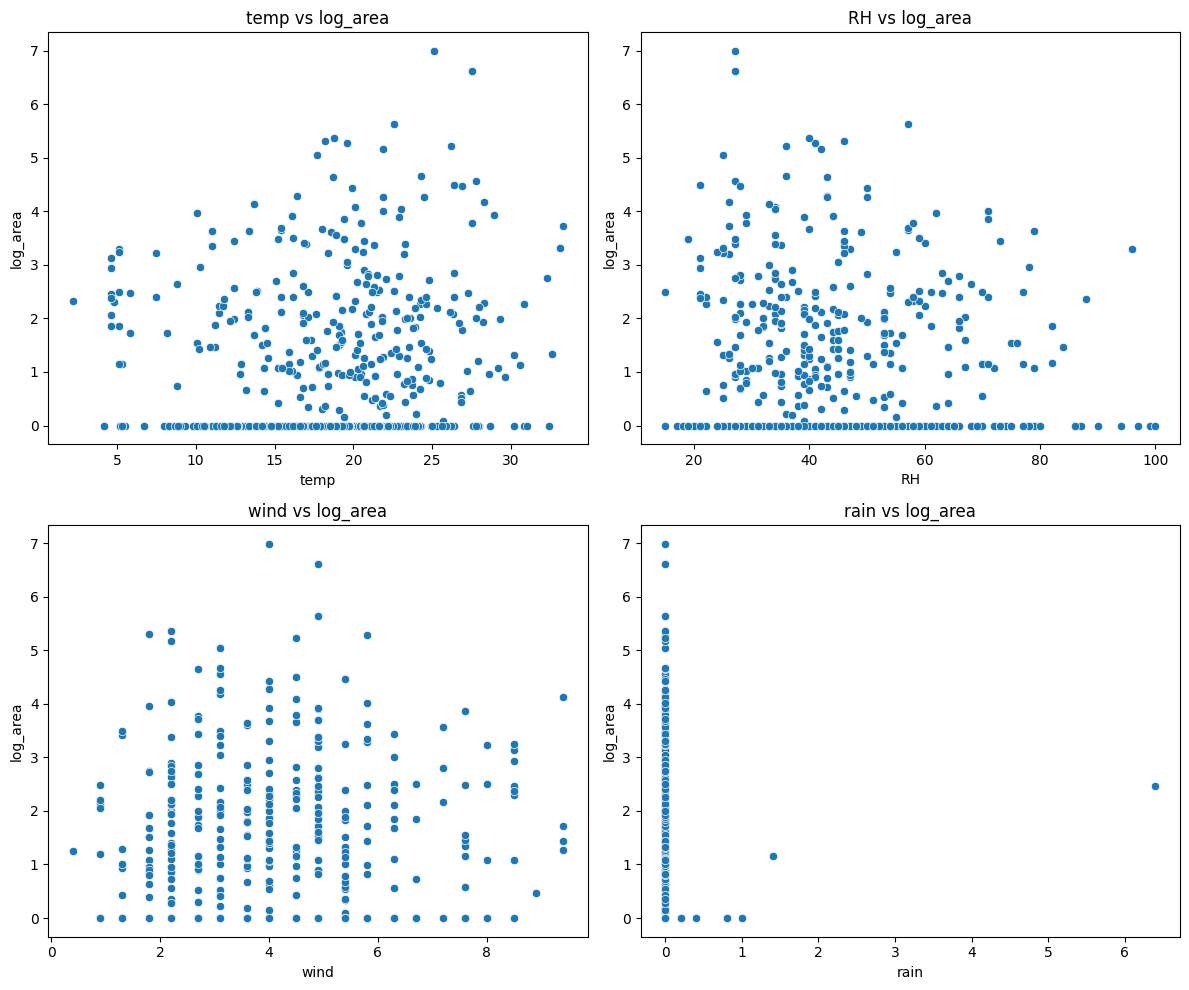

In [68]:
fig, axes = plt.subplots(2, 2, figsize= (12,10))
predictors = ['temp','RH','wind','rain']
axes = axes.flatten()
for i, col in enumerate(predictors):
    sns.scatterplot(x=data[col], y=data['log_area'], ax=axes[i])
    axes[i].set_title(f'{col} vs log_area')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log_area')

plt.tight_layout()
plt.show()

In [ ]:
log_model = smf.ols('log_area ~ temp + temp2 + rain + RH + is_dry_day', data=data).fit()
log_model.summary()

# significant negative linear effect — fire area decreases with temp initially
# Significant positive curvature — fire area increases again at higher temps

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_area   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     2.370
Date:                Sat, 25 Oct 2025   Prob (F-statistic):             0.0384
Time:                        22:46:39   Log-Likelihood:                -900.54
No. Observations:                 517   AIC:                             1813.
Df Residuals:                     511   BIC:                             1839.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.4840      0.614      4.045      0.000       1.278       3.690
temp          -0.1321      0.048     -2.765      0.006      -0.226      -0.038
temp2          0.0040      0.001      3.037      0.003       0.001       0.007
rain           0.0889      0.210      0.423      0.672      -0.324       0.502
RH            -0.0073      0.006     -1.175      0.241      -0.020       0.005
is_dry_day    -0.2163      0.193     -1.118      0.264      -0.596       0.164
==============================================================================
Omnibus:                       94.745   Durbin-Watson:                   0.956
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              145.358
Skew:                           1.208   Prob(JB):                     2.73e-32
Kurtosis:                       3.955   Cond. No.                     4.57e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.57e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

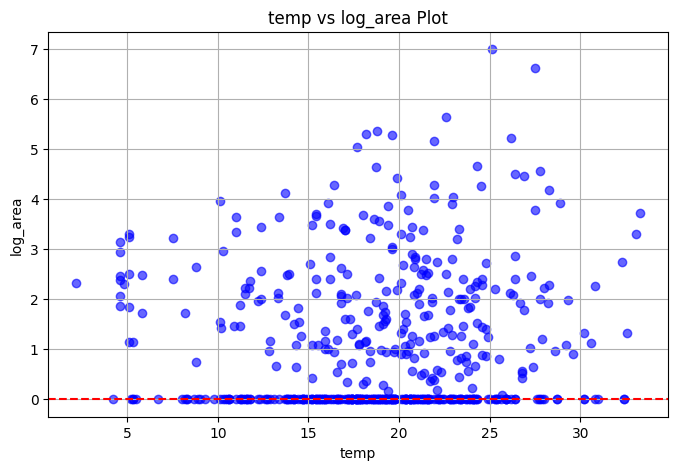

In [70]:
plt.figure(figsize=(8,5))
plt.scatter(data['temp'], data['log_area'], color = 'blue', alpha= 0.6)
plt.axhline(0, color= 'red', linestyle ='--')
plt.title('temp vs log_area Plot')
plt.xlabel('temp')
plt.ylabel('log_area')
plt.grid(True)
plt.show()

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [109]:
model_comparison_rsquared ={'Model':['Quadratic', 'Interaction', 'Indicator', 'Log-Transformed'], 
                   'R-squared': [quad_model.rsquared,interaction_model.rsquared,indicator_model.rsquared,log_model.rsquared]}

model_comparison_df_rsquared = pd.DataFrame(model_comparison_rsquared)
model_comparison_df_rsquared = model_comparison_df_rsquared.sort_values(by='R-squared', ascending=False)
model_comparison_df_rsquared 

,Model,R-squared
3,Log-Transformed,0.022664
1,Interaction,0.013648
0,Quadratic,0.011277
2,Indicator,0.010495


In [108]:
model_comparison_adj ={'Model':['Quadratic', 'Interaction', 'Indicator', 'Log-Transformed'], 
                   'Adjusted R-squared': [quad_model.rsquared_adj,interaction_model.rsquared_adj,indicator_model.rsquared_adj,log_model.rsquared_adj]}

model_comparison_df_adj = pd.DataFrame(model_comparison_adj)
model_comparison_df_adj = model_comparison_df_adj.sort_values(by='Adjusted R-squared', ascending=False)
model_comparison_df_adj 


,Model,Adjusted R-squared
3,Log-Transformed,0.013101
0,Quadratic,0.007430
2,Indicator,0.002765
1,Interaction,0.002044


In [106]:
model_comparison_aic ={'Model':['Quadratic', 'Interaction', 'Indicator', 'Log-Transformed'], 
                   'Adjusted R-squared': [quad_model.aic,interaction_model.aic, indicator_model.aic, log_model.aic]}

model_comparison_df_aic = pd.DataFrame(model_comparison_aic)
model_comparison_df_aic = model_comparison_df_aic.sort_values(by='Adjusted R-squared', ascending=True)
model_comparison_df_aic 

,Model,Adjusted R-squared
3,Log-Transformed,1813.085964
0,Quadratic,5761.027521
2,Indicator,5765.436128
1,Interaction,5767.786277


In [107]:
model_comparison_bic ={'Model':['Quadratic', 'Interaction', 'Indicator', 'Log-Transformed'], 
                   'Adjusted R-squared': [quad_model.bic,interaction_model.bic, indicator_model.bic, log_model.bic]}

model_comparison_df_bic = pd.DataFrame(model_comparison_bic)
model_comparison_df_bic = model_comparison_df_bic.sort_values(by='Adjusted R-squared', ascending=True)
model_comparison_df_bic

,Model,Adjusted R-squared
3,Log-Transformed,1838.574222
0,Quadratic,5773.771649
2,Indicator,5786.676342
1,Interaction,5797.522577


In [88]:
influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]

# Flag influential points
threshold = 4 / len(cooks_d)
influential_points = np.where(cooks_d > threshold)[0]
print(f"Influential points: {influential_points}")

Influential points: [ 28  61 104 211 228 230 231 234 235 236 237 238 276 278 281 282 284 293
 377 379 394 395 415 420 421 479 481 483 484 491 492 493 498 504]


### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(dX, dy, test_size=0.2, random_state=42)

# Ridge regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)


In [91]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_pred)

In [92]:
print(f"Ridge Test MSE: {ridge_mse:.3f}")
print(f"Lasso Test MSE: {lasso_mse:.3f}")
print("Ridge Coefficients:", ridge.coef_)
print("Lasso Coefficients: ",lasso.coef_)

Ridge Test MSE: 11748.631
Lasso Test MSE: 11749.831
Ridge Coefficients: [ 8.67707296e-01  1.10192139e-04  9.68807236e-01 -2.07857371e+00]
Lasso Coefficients:  [ 0.85158377 -0.0037228   0.92178849 -1.10790453]


In [ ]:
# The ridge and Lasso mean squared is almost identical but the ridge is a little bit smaller


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [97]:
threshold = data['area'].median()
data['is_fire_day'] = (data['area']> threshold).astype(int)

In [98]:
features = ['temp', 'RH', 'wind', 'rain', 'is_dry_day']
fX = data[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(fX)

### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [99]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_scaled, data['is_fire_day'], test_size=0.3, random_state=42)
model2 = LogisticRegression()
model2.fit(X_train2, y_train2)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [100]:
print("Intercept:", model2.intercept_[0])
print("Coefficients:", dict(zip(features, model2.coef_[0])))

Intercept: 0.010811949773058077
Coefficients: {'temp': 0.1447654865852221, 'RH': -0.07416471805106772, 'wind': 0.20744366244124773, 'rain': 0.03287233368668067, 'is_dry_day': -0.25830098101298604}


In [101]:
y_prob = model2.predict_proba(X_test2)[:, 1]
y_pred = model2.predict(X_test2)

In [104]:
print("Accuracy:", accuracy_score(y_test2, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test2, y_pred))
print("Precision:", precision_score(y_test2, y_pred))
print("Recall:", recall_score(y_test2, y_pred))
print("F1 Score:", f1_score(y_test2, y_pred))
print(classification_report(y_test2, y_pred, target_names=['Low Fire', 'High Fire']))

Accuracy: 0.48717948717948717
Confusion Matrix:
 [[39 40]
 [40 37]]
Precision: 0.4805194805194805
Recall: 0.4805194805194805
F1 Score: 0.4805194805194805
              precision    recall  f1-score   support

    Low Fire       0.49      0.49      0.49        79
   High Fire       0.48      0.48      0.48        77

    accuracy                           0.49       156
   macro avg       0.49      0.49      0.49       156
weighted avg       0.49      0.49      0.49       156



### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [105]:
vif_data = pd.DataFrame()
vif_data['Variable'] = dX.columns
vif_data['VIF'] =[ variance_inflation_factor(dX.values, i) for i in range(dX.shape[1])]
vif_data

,Variable,VIF
0,temp,4.248688
1,RH,4.869825
2,wind,4.932364
3,rain,1.010755


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

[Type your findings here.]

## The findings in the data

In [111]:
print("""
- In the first plot the Residuals and fitted values. There are two extreme outliers that need looked at.
- Out of the 4 model the log Transformed model is the best fitting model. So log area captures more variance the best
- There are a lot of influential points that is distorting coefficients and fit. Compare model with and without the influential point
- The ridge and Lasso mean squared is almost identical but the ridge is a little bit smaller
- The coefficient show that temp (0.8516)Ridge (0.8516)Lasso is a strong predictor
- There clusters are plotted near zero in the Y axes it look like small area fires dominate the data set
- In the rain plot the X value are near zero. It likely do to little rainfall
- In the Log area model temp2 is Significant (p = 0.003) suggesting that temperature have a impact in the area
- There was a strong negative correlation (-0.53)temperature vs Relative Humidity 
- It look like Temp vs Wind mild negative correlation (-0.23) and in the Rain column are near zero 
- The Confusion Matrix show that the model confused both classes. Which suggested there are not strong signal.
- Accuracy (48%) show that model separating class well
- Precision (48%) it predict fire (48%) of the time
- Recall (48%) it detects of actual fire days 
- F1 - score (48%) precision and recall is weak
- VIF - temp (4.25) moderate multicollinearity shares variance RH and wind 
      - RH (4.87) high  multicollinearity shares variance temp and wind 
      - Wind (4.93) highest multicollinearity shares variance temp and RH
      - Rain (1.01) Very low no multicollinearity
""")


- In the first plot the Residuals and fitted values. There are two extreme outliers that need looked at.
- Out of the 4 model the log Transformed model is the best fitting model. So log area captures more variance the best
- There are a lot of influential points that is distorting coefficients and fit. Compare model with and without the influential point
- The ridge and Lasso mean squared is almost identical but the ridge is a little bit smaller
- The coefficient show that temp (0.8516)Ridge (0.8516)Lasso is a strong predictor
- There clusters are plotted near zero in the Y axes it look like small area fires dominate the data set
- In the rain plot the X value are near zero. It likely do to little rainfall
- In the Log area model temp2 is Significant (p = 0.003) suggesting that temperature have a impact in the area
- There was a strong negative correlation (-0.53)temperature vs Relative Humidity 
- It look like Temp vs Wind mild negative correlation (-0.23) and in the Rain column are 